<figure>
  <IMG SRC="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d5/Fachhochschule_Südwestfalen_20xx_logo.svg/320px-Fachhochschule_Südwestfalen_20xx_logo.svg.png" WIDTH=250 ALIGN="right">
</figure>

# Einführung Machine Learning
### Sommersemester 2026
Prof. Dr. Heiner Giefers

# Mini-Beispiel für eine ML-Anwendung in Python

In dieser Aufgabe wollen wir ein kleines Machine-Learning-Beispiel mit Python umsetzen. Viele der Teilschritte werden Sie erst später genauer kennenlernen. Es soll hier zunächst nur darum gehen zu sehen, dass sich ein Beispiel, das wir zuvor grafisch mit Orange3 umgesetzt haben, auch mit sehr wenig Python-Code nachbilden lässt.

## Schritt 1: Datensatz laden und einen Entscheidungsbaum auf allen verfügbaren Daten trainieren

Im ersten Schritt wird ein Klassifikationsdatensatz aus der Python Bibliothek `scikit-learn` geladen. Der Datensatz *wine* enthält verschiedene chemische Messwerte von Weinen sowie die zugehörige Klassenzugehörigkeit.

Anschließend wird ein Entscheidungsbaum-Klassifikator erzeugt und direkt auf dem gesamten Datensatz trainiert. Ziel ist es hier nicht, ein optimales Modell zu entwickeln, sondern zu demonstrieren, wie einfach sich ein lauffähiges Machine-Learning-Modell in Python erstellen lässt.

Die Bewertung des Modells erfolgt ebenfalls auf den Trainingsdaten. Diese Vorgehensweise ist bewusst vereinfacht und führt typischerweise zu einer sehr hohen Accuracy. Dieser Wert ist jedoch mit Vorsicht zu interpretieren, da das Modell die Daten bereits kennt und daher keine Aussage über die Qualität auf unbekannten Daten getroffen werden kann.

In [2]:
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Datensatz laden
data = load_wine()
X, y = data.data, data.target

# Entscheidungsbaum auf allen Daten trainieren
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X, y)

# Vorhersage auf den Trainingsdaten
train_acc = accuracy_score(y, tree.predict(X))

print("Accuracy auf allen Daten:", round(train_acc, 3))
print("Baumtiefe:", tree.get_depth())

Accuracy auf allen Daten: 1.0
Baumtiefe: 5


X sind die Eingabedaten (Featrues und Messwerte: woraus das Modell lernt) und Y sind die Antworten (Zielvariable: was das Modell vorhersagen soll).

**Fit:** ist das Training, in dem der Baum die Daten anschaut und seine Regeln aufbaut.

**DecisionTreeClassifier(random_state=0)** erzeugt einen leeren, untrainierten Entscheidungsbaum – quasi den Learner. Er weiß noch nichts, hat keine Regeln, hat keine Daten gesehen. Er ist nur bereit zum Lernen.

**Random state = 0** , sorgt dafür, dass der Baum bei jedem Durchlauf das gleiche Ergebnis liefert.

**tree.predict(X)**
Der trainierte Baum bekommt nochmal die Features (X) und macht für jeden Datenpunkt eine Vorhersage: "Diesen Wein halte ich für Sorte 0, den für Sorte 2, den für Sorte 1..."

Das Ergebnis ist eine Liste von vorhergesagten Klassen – quasi eine Spalte mit den Antworten des Baums.

In Orange war das der Moment, in dem das Predictions-Modul die Vorhersagen angezeigt hat (die Spalte "Tree" ganz links in der Tabelle).


**accuracy_score(y, tree.predict(X))**

Diese Funktion vergleicht zwei Listen miteinander:

* y = die echten Klassen (die richtigen Antworten)

* tree.predict(X) = die vorhergesagten Klassen (was der Baum denkt)

**train_acc**= ...
Das Ergebnis wird einfach in der Variable train_acc gespeichert, damit man es danach ausgeben kann.

**Fazit:** Das Ergebnis ist problematisch, weil der Baum auf denselben Daten getestet wurde, auf denen er trainiert wurde. Dies führt dazu, dass er die Antworten bereits kennt und somit keine verlässliche Aussage darüber getroffen werden kann, ob er auf neuen, unbekannten Daten genauso gut abschneidet.

## Schritt 2: Das Modell mit getrennten Trainings- und Testdaten bewerten

Im nächsten Schritt wird der Datensatz in Trainings- und Testdaten aufgeteilt. Der Trainingsdatensatz wird verwendet, um das Modell zu lernen, während der Testdatensatz erst nach dem Training zur Bewertung herangezogen wird.

Diese Trennung ist zentral für eine realistische Einschätzung der Modellqualität, da sie simuliert, wie gut das Modell auf bisher unbekannten Daten funktioniert.

Typischerweise fällt die Accuracy auf den Testdaten niedriger aus als auf den Trainingsdaten. Das ist ein Hinweis darauf, dass das Modell nicht perfekt generalisiert und möglicherweise bereits beginnt, sich zu stark an die Trainingsdaten anzupassen.

In [3]:
from sklearn.model_selection import train_test_split

# Aufteilung in Trainings- und Testdaten
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# Neues Modell trainieren
tree_split = DecisionTreeClassifier(random_state=0)
tree_split.fit(X_train, y_train)

# Bewertung auf den Testdaten
test_acc = accuracy_score(y_test, tree_split.predict(X_test))
print("Accuracy mit Train/Test-Split:", round(test_acc, 3)) #rundet 3 nachkommastellen
print("Baumtiefe:", tree_split.get_depth())

Accuracy mit Train/Test-Split: 0.933
Baumtiefe: 4


## Schritt 3: Den Entscheidungsbaum visualisieren

In diesem Schritt wird der trainierte Entscheidungsbaum grafisch dargestellt. Entscheidungsbäume sind im Vergleich zu vielen anderen Machine-Learning-Modellen gut interpretierbar, da ihre Struktur explizit nachvollzogen werden kann.

Jeder innere Knoten im Baum entspricht einer Entscheidungsregel auf Basis eines Merkmals (z.\,B. ein Schwellwertvergleich). Die Blätter enthalten die resultierenden Klassenzuweisungen. Durch das Durchlaufen des Baumes wird sichtbar, wie das Modell seine Entscheidungen trifft.

Die Visualisierung hilft dabei, die Komplexität des Modells zu beurteilen. Ein sehr tiefer oder stark verzweigter Baum kann ein Hinweis auf Overfitting sein, insbesondere wenn gleichzeitig eine deutliche Differenz zwischen Trainings- und Testgenauigkeit besteht.

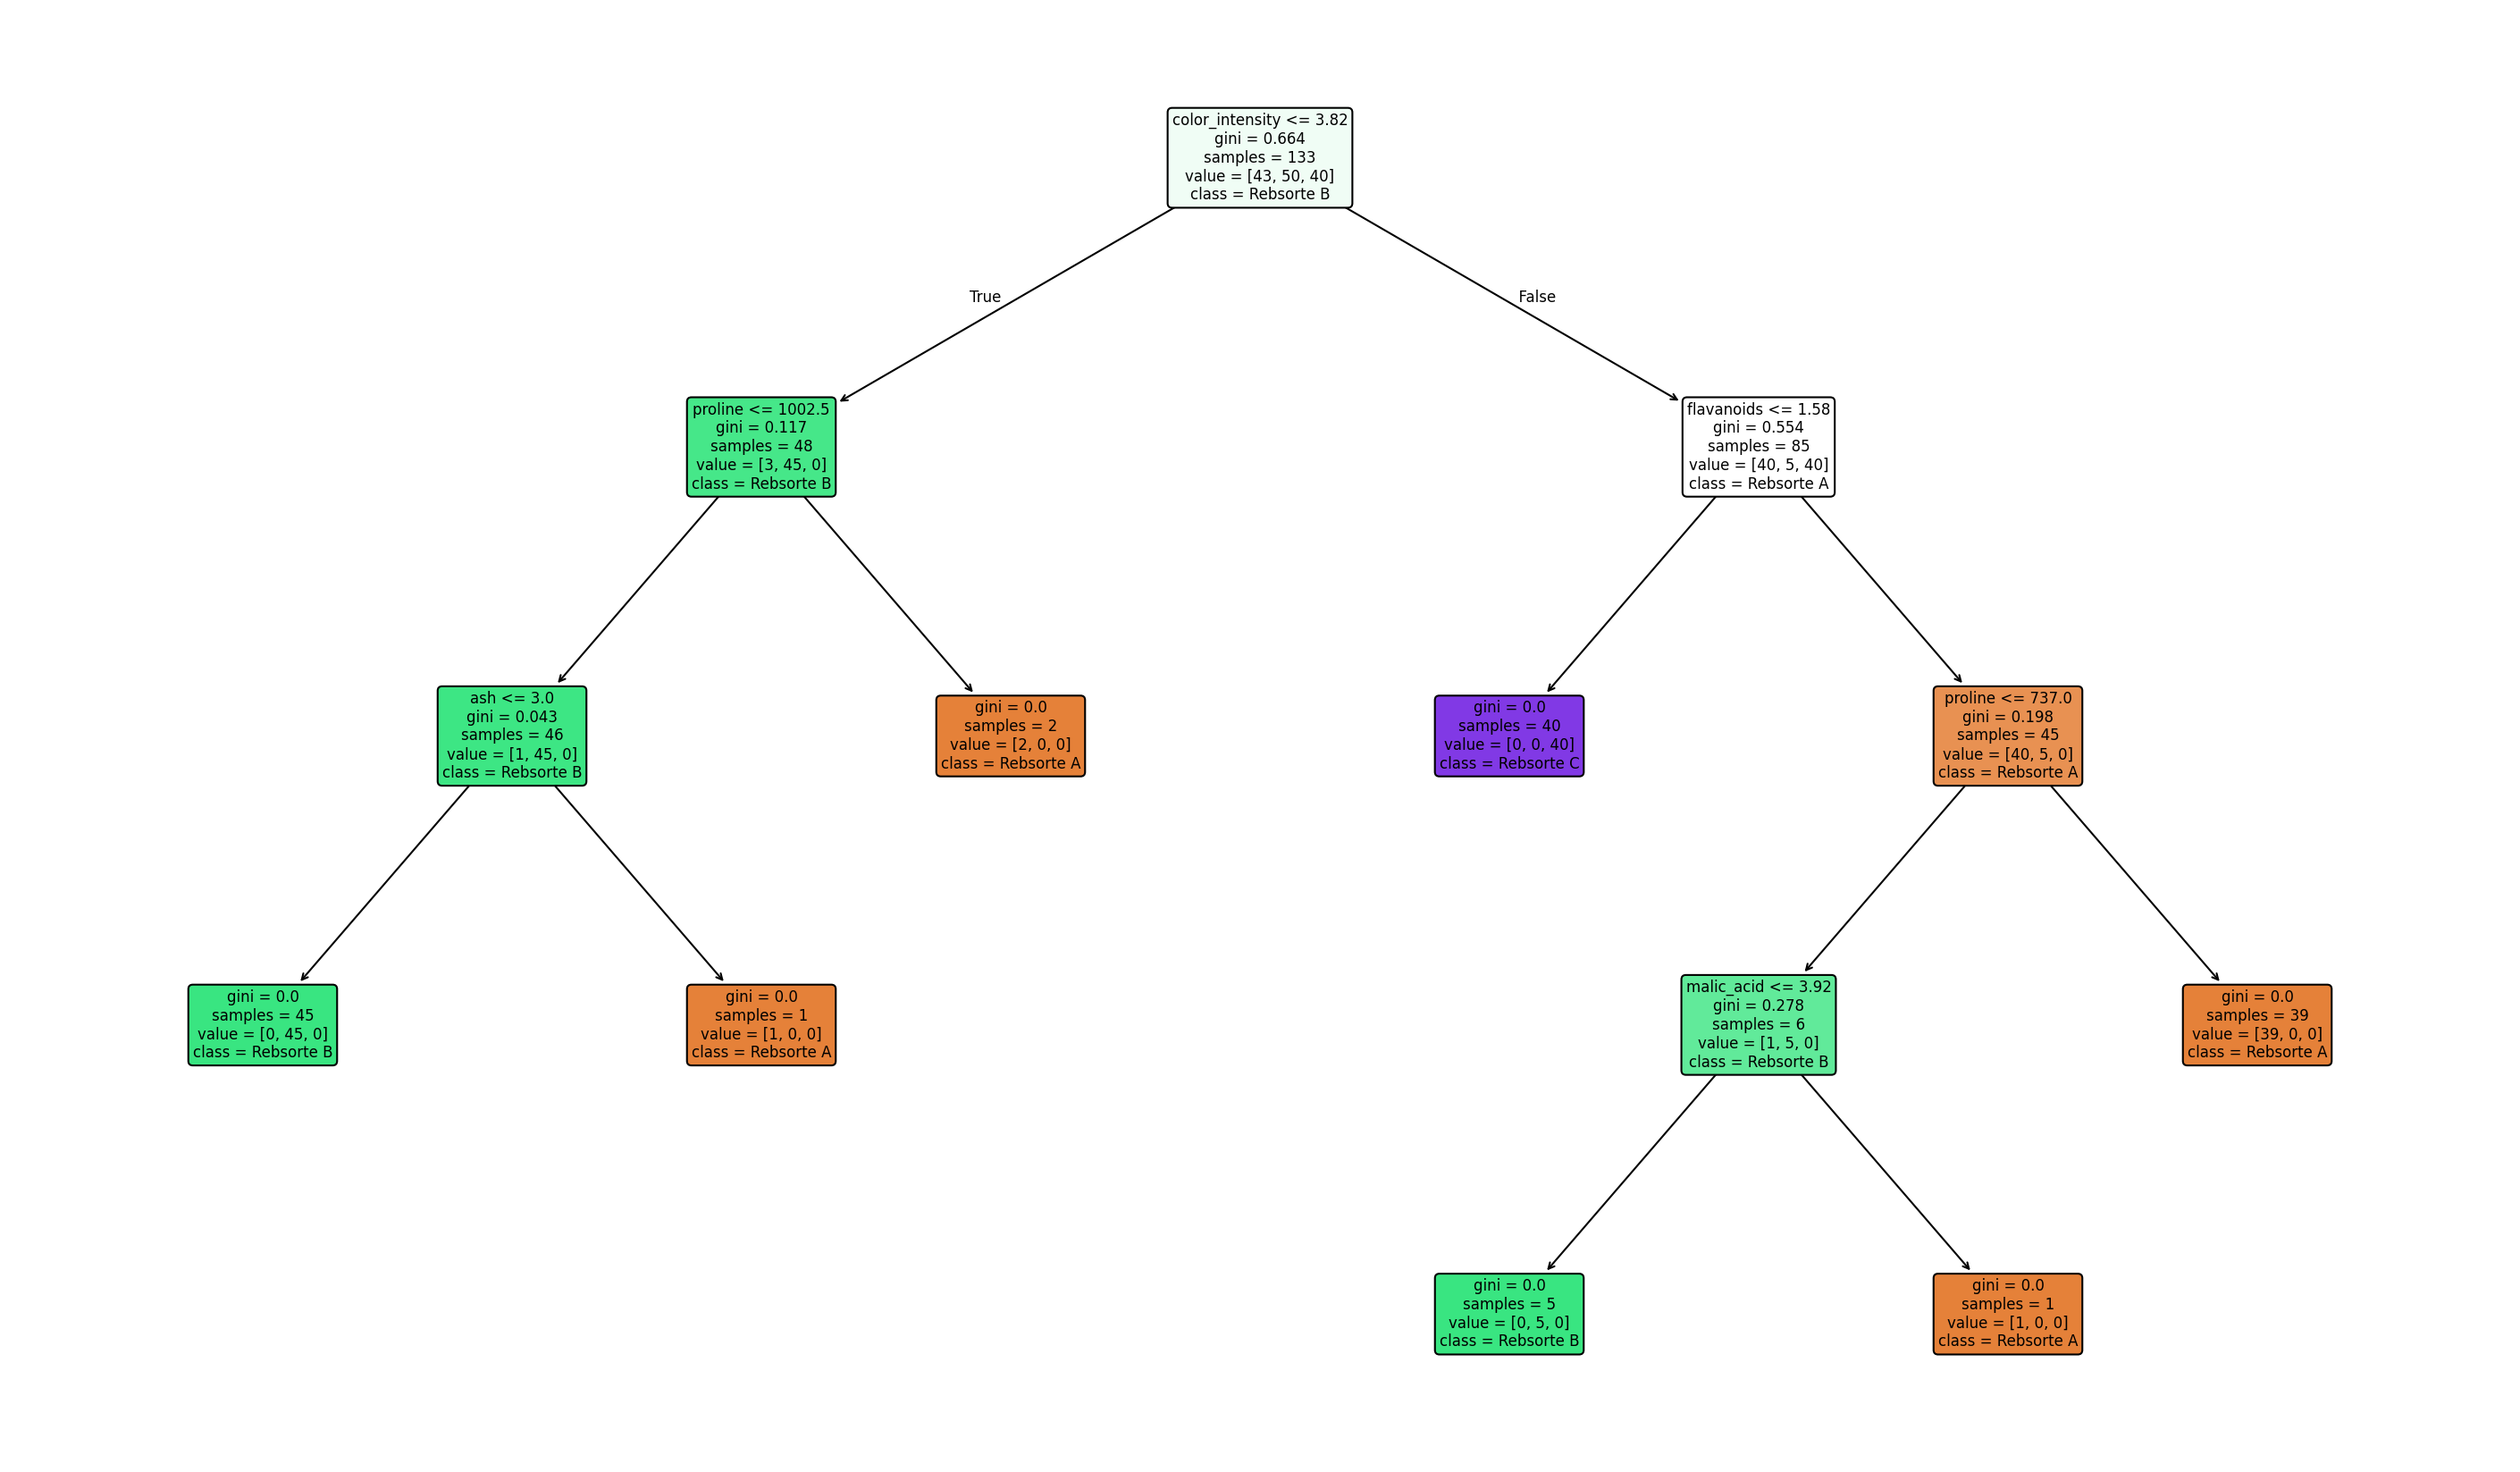

In [4]:
from sklearn.tree import plot_tree #plot_tree → kann Entscheidungsbäume zeichnen
import matplotlib.pyplot as plt #matplotlib.pyplot → die Standard-Bibliothek in Python für Grafiken und Diagramme (wird hier als plt abgekürzt)

#Leere Leinwand
plt.figure(figsize=(24, 14), dpi=150) #figsize=(24, 14) → die Größe: 24 breit, 14 hoch (in Zoll) \ dpi=150 → die Auflösung (dots per inch) – je höher, desto schärfer das Bild

#Baum zeichnen
plot_tree(
    tree_split, # Welcher Baum? -> aus Schritt 2
    feature_names=data.feature_names, # Die echten feature Namen angeben
    class_names = ["Rebsorte A", "Rebsorte B", "Rebsorte C"], # Zeige lesbare Klassennamen statt nur 0, 1, 2
    filled=True, # Knoten werden farbig gefüllt
    impurity=True,                 # kein Gini -> Wie gemischt ist ein Knoten?
    fontsize=8, #Schriftgroeße 8
    rounded=True #abgerundete Ecken
);